<a href="https://colab.research.google.com/github/dankd/NextGenWindSolarDemo/blob/main/NextGenWindSolarDemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_7834/2798907864.py:145: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  dni[k] = 0.0
/tmp/ipykernel_7834/2798907864.py:146: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  dhi[k] = 0.0
/tmp/ipykernel_7834/2798907864.py:149: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  dni[k] = 1000.0


Error in zenith angle calculation
100.0 1013.4497680664062
1970-01-01 00:00:00+00:00    0.0
1970-01-01 01:00:00+00:00    0.0
1970-01-01 02:00:00+00:00    0.0
1970-01-01 03:00:00+00:00    0.0
1970-01-01 04:00:00+00:00    0.0
                            ... 
2025-12-31 19:00:00+00:00    NaN
2025-12-31 20:00:00+00:00    NaN
2025-12-31 21:00:00+00:00    NaN
2025-12-31 22:00:00+00:00    NaN
2025-12-31 23:00:00+00:00    NaN
Freq: h, Name: Fenner, Length: 490896, dtype: float32


/usr/local/lib/python3.12/dist-packages/windpowerlib/data.py:443: WindpowerlibUserWarning: The following columns of the weather data contain invalid values like 'nan': [('wind_speed', 100.0), ('temperature', 2.0)]
  warnings.warn(msg.format(nan_columns), WindpowerlibUserWarning)
/usr/local/lib/python3.12/dist-packages/windpowerlib/data.py:443: WindpowerlibUserWarning: The following columns of the weather data contain invalid values like 'nan': [('wind_speed', 100.0), ('temperature', 2.0)]
  warnings.warn(msg.format(nan_columns), WindpowerlibUserWarning)


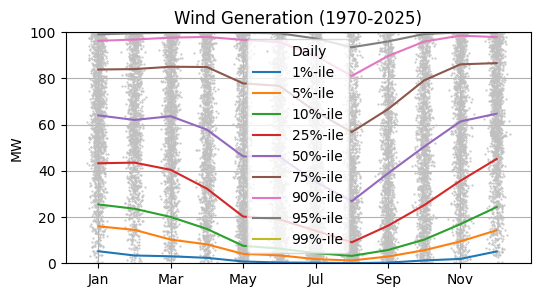

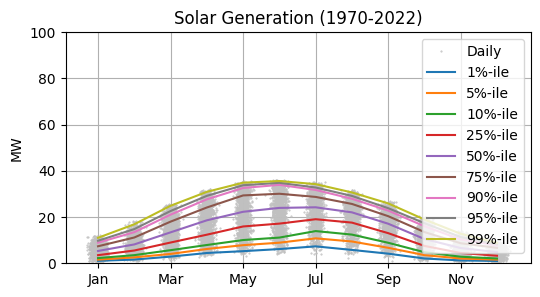

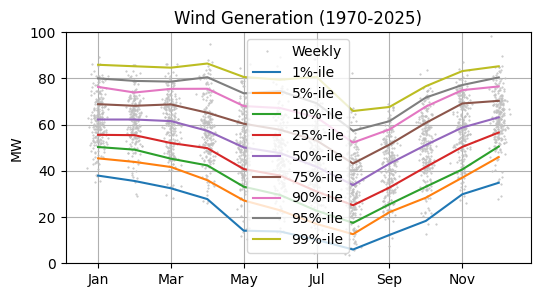

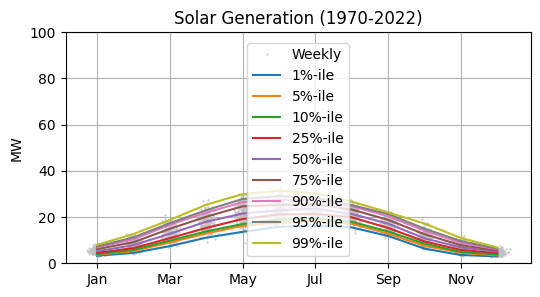

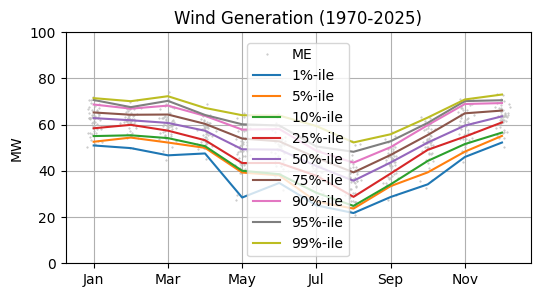

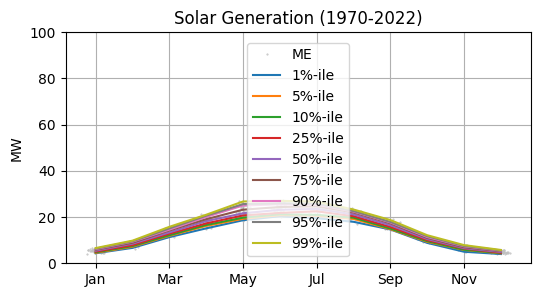

In [4]:
# -*- coding: utf-8 -*-
"""
Created on Thu June 18, 2026

@author: Dan Kirk-Davidoff
"""

!pip install windpowerlib
!pip install pvlib

import glob
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
from windpowerlib import data as wt
from windpowerlib import ModelChain, WindTurbine
from pvlib import pvsystem, location, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS as PARAMS
import xarray as xr
from windpowerlib import power_output
from windpowerlib import power_curves
from windpowerlib import wake_losses

from google.colab import drive
drive.mount('/content/drive')

def windToPow(S100,T,Farms,WakeLoss):
# Calculate power from wind farm using 100m wind speed (S100) and
# 2m air temperature
# Farms is a list of dictionaries with keys Project Name, Power Curve and
# Capacity

    tl0 = S100.shape
    if len(tl0)==1:
        tl = tl0[0]
        ll = 1
        Pow = pd.DataFrame(np.zeros((tl,ll)),index=S100.index,columns=['Dummy'])
    else:
        tl = tl0[0]
        ll = tl0[1]
        Pow = pd.DataFrame(np.zeros((tl,ll)),index=S100.index,columns=S100.columns)
    for i,col in enumerate(Pow.columns):
        if Farms[i]['Capacity']>0:
            tl,ll = Pow.shape
            if ll>1:
                dum0 = S100[col].values[:,0]
                dum1 = T[col].values[:,0]
            elif ll==1:
                dum0 = S100.values[:,0]
                dum1 = T.values[:,0]
            else:
                dum0 = S100.values
                dum1 = T.values
            if WakeLoss:
                # Implement wake losses, assuming we're using a single turbine
                # to represent a a whole wind farm.
                dum0 = wake_losses.reduce_wind_speed(pd.Series(dum0,
                                    index=S100.index),
                                    wind_efficiency_curve_name='knorr_extreme3')
            # Compile weather data frame, using multi-line column headers to
            # specify the variables included and the measurement height at which
            # they are observed
            weather = pd.DataFrame(np.vstack([0.1*np.ones(tl),
                dum0,dum1, 101300.0*np.ones(tl)]).T,
                index=S100.index, columns = pd.MultiIndex.from_arrays(
                    [['roughness_length',
                  'wind_speed', 'temperature','pressure'],
                   [0.0, 100.0, 2.0, 0.0]],
                names=('variable_name', 'height')),dtype=float)
            # An example of a set-up to use different power curves for different
            # wind farms.

            mc = ModelChain(Farms[i]['Power Curve'], **modelchain_data).run_model(weather)
            mxcp = Farms[i]['Power Curve'].nominal_power

            pout = mc.power_output.to_numpy()
            Pow[col] = pout/mxcp*Farms[i]['Capacity']

    return Pow


def ghiToPow(G,T,S10,Tracking,Cap,Lat,Lon,tilt):
# Calls pvlib to calculate power from a solar plant driven by ghi (G),
# temperature at 2m height, and wind speed at 10m height.
# Tracking can be "fixed" or "single" for single-axis tracking

# create site system characteristics

    sandia_modules = pvsystem.retrieve_sam('SandiaMod')
    module = sandia_modules['Canadian_Solar_CS5P_220M___2009_']

    temperature_model_parameters = PARAMS['sapm']['open_rack_glass_glass']

    sapm_inverters = pvsystem.retrieve_sam('cecinverter')
    inverter = sapm_inverters['ABB__MICRO_0_25_I_OUTD_US_208__208V_']
    inverter.Paco = 176
    inverter.Pdco = 190

# Set up dataframes for power calculation
    if len(G.shape)>1:
        Pow = pd.DataFrame(index=G.index,columns=G.columns)
    else:
        Pow = pd.DataFrame(index=G.index,columns=['Dummy'])
        G = pd.DataFrame(G.values,index=G.index,columns=['Dummy'])
        T = pd.DataFrame(T.values,index=T.index,columns=['Dummy'])
        S10 = pd.DataFrame(S10.values,index=S10.index,columns=['Dummy'])
    for i,col in enumerate(Pow.columns):
       # Set up mounting for pvsystem.Array
        if Tracking=='fixed':
            mount = pvsystem.FixedMount(surface_tilt =
                Lat[i]+tilt, surface_azimuth=180.0)
        elif Tracking=='single':
            mount = pvsystem.SingleAxisTrackerMount(
                axis_tilt=0.0, axis_azimuth=0.0,
                max_angle=90.0, backtrack=True,
                gcr=0.285714, cross_axis_tilt= 0.0,
                racking_model=None,
                module_height=None)
        #Complete setup of power system
        pvarray = pvsystem.Array(
            mount=mount,
            module_parameters=module,
            temperature_model_parameters=temperature_model_parameters)

        pvsys = pvsystem.PVSystem(arrays=[pvarray],
                                  inverter_parameters=inverter)

        #Set up clearsky radiance calculation
        loc = location.Location(latitude=Lat[i],longitude=Lon[i],tz='Etc/GMT')
        #Finalize model object set-up.
        mc_solar = modelchain.ModelChain(pvsys,loc,aoi_model="physical",
                                          spectral_model="first_solar")

        ghi = G[col]
        clsky = loc.get_clearsky(G.index)
        #Estimate dni and dhi as fraction ghi/clearsky['ghi'] of their
        # clearsky values
        dni = (ghi*clsky['dni'].\
            to_numpy()/(clsky['ghi'].to_numpy()+0.01))
        dhi = (ghi*clsky['dhi'].\
            to_numpy()/(clsky['ghi'].to_numpy()+0.01))
        #Get rid of any weird negative radiances
        k = np.where(ghi<1.0)[0]
        dni[k] = 0.0
        dhi[k] = 0.0
        #Get rid of any over-bright radiances
        k = np.where(dni>1100)[0]
        dni[k] = 1000.0

        #Convert to Celsius from Kelvin if appropriate
        if T[col].mean()>200:
          t2m = T[col]-273.15
          t2m[t2m<-100] = 0.0
        #Set up weather variables dataframe
        weather = pd.DataFrame(np.vstack([ghi,dni,dhi,
                t2m,S10[col]]).T,index=G.index,
                columns=['ghi','dni','dhi','temp_air','wind_speed'],dtype=float)

        #Run model
        try:
            mc_solar.run_model(weather)
            pout = mc_solar.results.ac.to_numpy()
            print(np.nanmax(pout),inverter.Paco,Cap[i])
            pout = pout*Cap[i]/inverter.Paco
        except:
            print('Error in zenith angle calculation')
            print(Cap[i],np.max(ghi))
            print(ghi)
            pout = ghi*Cap[i]/np.max(ghi)
        Pow[col] = pout

    return Pow


# Simple Load Model
def tempsToLoad(T,coeffs):
    #Calculates load assuming a fixed diurnal and weekday cycle and a piecewise
    #linear temperature dependence (dependent only on the daily average temperature)

    Load = pd.DataFrame(np.zeros_like(T.values),index=T.index,
                        columns=list(coeffs.keys()))

    for col in coeffs.keys():

        Tc = 15.0+273.15 #Ambient temperature above which cooling is required
        Th = 5.0+273.15  #Ambient temperature below which heating is required
        #Calculate rolling daily mean temperature
        Trm = T[col].shift(freq='-12H').rolling('D').mean().reindex(T.index)

        #Calculate Day-of-Week load variability
        DoWL = pd.Series(np.ones(len(T[col]))*coeffs[col]['basel'],index=T.index)
        DoWL[(T.index.dayofweek<4)|(T.index.dayofweek==6)] += coeffs[col]['dow']
        DoWL =  DoWL.shift(freq='-12H').rolling('D').mean()

        #Calculate Hour-of-Day load variability
        HoDL = pd.Series(coeffs[col]['diurnal']*(np.sin(np.pi*(T.index.hour -\
                7)/12) + 0.25*np.sin(np.pi*(T.index.hour-3)/6)),index=T.index)

        #Calculate Weather Driven Load

        WDL = pd.Series(np.zeros_like(T[col]),index=T.index)

        #Temperatures above Tc result in cooling load
        WDL[Trm>Tc] = WDL[Trm>Tc]+ (Trm[Trm>Tc]-Tc)*coeffs[col]['coeffc']
        #Temperatures below Th result in heating load
        WDL[Trm<Th] = WDL[Trm<Th] + (Th-Trm[Trm<Th])*coeffs[col]['coeffw']

        Load[col] = WDL + HoDL + DoWL

    Load = Load[list(coeffs.keys())].sum(axis=1)

    return Load

# Quantile Climatology Plot

def quantileClimatologyPlot(df,avgp,qts,title,ylim,units):
    avgplabel = {'D':'Daily','3D':'Three Daily','7D':'Weekly','W':'Weekly',
                 '2W':'Biweekly','14D':'Biweekly','M':'Monthly','5D':'Pentad',
                 '10D':'Decad'}
    try:
        avgpl = avgplabel[avgp]
    except KeyError:
        avgpl = avgp
    qtlabels = [str(int(qt*100))+'%-ile' for qt in qts]
    dfavg = df.resample(avgp).mean()
    jitter = np.random.normal(0,0.1,len(dfavg.index))
    fig = plt.figure(figsize=(6,3))
    ax = fig.add_subplot()
    ax.plot(dfavg.index.month+jitter,dfavg,'.',color='#C0C0C0',markersize=1)
    for qt in qts:
        ax.plot(np.arange(1,13),dfavg.groupby(dfavg.index.month).\
        quantile(qt))
    ax.set_xticks(np.arange(1,12,2),labels=['Jan','Mar','May','Jul','Sep','Nov'])
    ax.legend([avgpl]+qtlabels)
    ax.set(ylim=ylim,ylabel=units)
    ax.grid()
    ax.set_title(title)
    plt.show()


def quantileClimatologyPlotWithTemp(df,temp,avgp,qts,title,ylim,units):
    avgplabel = {'D':'Daily','3D':'Three Daily','7D':'Weekly','W':'Weekly',
                 '2W':'Biweekly','14D':'Biweekly','M':'Monthly','5D':'Pentad',
                 '10D':'Decad'}
    tempd = temp.rolling(24).mean()
    try:
        avgpl = avgplabel[avgp]
    except KeyError:
        avgpl = avgp
    qtlabels = [str(int(qt*100))+'%-ile' for qt in qts]
    dfavg = df.resample(avgp).mean()
    jitter = np.random.normal(0,0.1,len(dfavg.index))
    plt.figure(figsize=(6,3))
    for i in range(1,13):
        tempd = temp.rolling(24).mean().resample(avgp).mean()[temp.\
                                      resample(avgp).mean().index.month==i]
        dfavg = df.resample(avgp).mean()\
                   [df.resample(avgp).mean().index.month==i]
        jitter = np.random.normal(0,0.1,len(dfavg.index))
        k25 = np.where(tempd<tempd.quantile(.25))[0]
        k50 = np.where((tempd>=tempd.quantile(.25))&\
                  (tempd<=tempd.quantile(.75)))[0]
        k75 = np.where(tempd>tempd.quantile(0.75))[0]
        print(len(k25),len(k50),len(k75))
        p1, = plt.plot(dfavg.index.month[k25]+jitter[k25],dfavg.iloc[k25],'.',
                       color='#1010EE',markersize=1,label=avgpl+'Cold')
        p2, = plt.plot(dfavg.index.month[k50]+jitter[k50],dfavg.iloc[k50],'.',
                       color='#C0C0C0',markersize=1,label=avgpl)
        p3, = plt.plot(dfavg.index.month[k75]+jitter[k75],dfavg.iloc[k75],'.',
                       color='#EE1010',markersize=1,label=avgpl+'Hot')

    dfavg = df.resample(avgp).mean()
    qleg = []
    for qt in qts:
        pp, = plt.plot(dfavg.groupby(dfavg.index.month).quantile(qt))
        qleg.append(pp)
    plt.xticks(np.arange(1,12,2),labels=['Jan','Mar','May','Jul','Sep','Nov'])
    plt.legend([p1,p2,p3]+qleg,[avgpl+'Cold',avgpl,avgpl+'Warm']+qtlabels,loc=1)
    plt.ylim(ylim)
    plt.xlim(0,18)
    plt.grid()
    plt.ylabel(units)
    plt.title(title)
    plt.show()


#  Diurnal Cycle Climatology Plot

def quantileClimoDiurnalPlot(df,month,qts,title,xlim, ylim,units):
    monlab = pd.to_datetime('2010-'+'{:02}'.format(month)).strftime('%B')
    xlab = str(df.index[0].tz)
    qtlabels = [str(int(qt*100))+'%-ile' for qt in qts]
    k = np.where(df.index.month==month)[0]
    dfm = df.iloc[k]
    dfm.index = dfm.index.tz_convert('Asia/Riyadh')
    jitter = np.random.normal(0,0.1,len(dfm.index))
    plt.plot(dfm.index.hour+jitter,dfm,'.',color='#C0C0C0',markersize=1)
    for qt in qts:
        dfm.groupby(dfm.index.hour).\
            quantile(qt).plot(legend=False)
    plt.legend(['Hourly']+qtlabels)
    plt.ylim(ylim)
    plt.xlim(xlim)
    plt.grid()
    plt.xlabel(xlab)
    plt.ylabel(units)
    plt.title(title+' for '+monlab)
    plt.show()


#Initialize windpowerlib settings for calculation of wind generation from ERA5
#Winds

datadir = r'/content/drive/MyDrive/Colab Data/NextGenDemo'

# Load power curve data
curvefile = r'/PowerCurves.xlsx'
curves = pd.read_excel(datadir+curvefile)

#Define WT5 as EN182 5.0 MW Wind Turbine
spds = np.arange(0,25,0.1)
rho = 1.25*np.ones_like(spds)

pcurve = power_curves.create_power_curve(curves['Wind Speed (m/s)'],
        curves['EN182 5.0 MW'])
pcurve2 = power_output.power_curve(spds,pcurve['wind_speed'],pcurve['value'],
            density=1.25/1.05*1.25*np.ones_like(spds),density_correction=True)
pcurve = power_curves.create_power_curve(spds, pcurve2)
WT5 = WindTurbine(hub_height=120,nominal_power=5000.0,power_curve=pcurve,
                      rotor_diameter=182)

#Define WT8 as EN182 8.0 MW Wind Turbine
pcurve = power_curves.create_power_curve(curves['Wind Speed (m/s)'],
        curves['EN182 8.0 MW'])
pcurve2 = power_output.power_curve(spds,pcurve['wind_speed'],pcurve['value'],
            density=1.25/1.05*1.25*np.ones_like(spds),density_correction=True)
pcurve = power_curves.create_power_curve(spds, pcurve2)

WT8 = WindTurbine(hub_height=120,nominal_power=8000.0,power_curve=pcurve,
                      rotor_diameter=182)


#Define WT75 as GWH182-7.5 7.5 MW Wind Turbine
pcurve = power_curves.create_power_curve(curves['Wind Speed (m/s)'],
        curves['GWH182-7.5 MW'])
pcurve2 = power_output.power_curve(spds,pcurve['wind_speed'],pcurve['value'],
            density=1.25/1.134*1.25*np.ones_like(spds),density_correction=True)
pcurve = power_curves.create_power_curve(spds, pcurve2)
WT7p5 = WindTurbine(hub_height=120,nominal_power=7500.0,power_curve=pcurve,
                      rotor_diameter=182)


modelchain_data = {
    'wind_speed_model': 'logarithmic',  # 'logarithmic' (default),
    # 'hellman' or
    # 'interpolation_extrapolation'
    'density_model': 'ideal_gas',  # 'barometric' (default), 'ideal_gas'
    #  or 'interpolation_extrapolation'
    'temperature_model': 'linear_gradient',  # 'linear_gradient' (def.) or
    # 'interpolation_extrapolation'
    'power_output_model':
        'power_curve',  # 'power_curve' (default) or
    # 'power_coefficient_curve'
    'density_correction': True,  # False (default) or True
    'obstacle_height': 0,  # default: 0
    'hellman_exp': None}  # None (default) or None

# initialize ModelChain with own specifications and use run_model method to
# calculate power output

#Initialize pvlib settings for calculation of solar generation from location,
#GHI and temperature



worldbd = gpd.read_file(datadir+r'/world-administrative-boundaries.shp')
era5 = pd.read_pickle(datadir+r'/WindSolarDemoFenner.pkl')

farmname = 'Fenner'
ghi = era5['ghi'].to_frame(farmname)
t2m = era5['t2m'].to_frame(farmname)
s10 = era5['s10'].to_frame(farmname)
s100 = era5['s100'].to_frame(farmname)


Lat = [42.98]
Lon = [284.24-360.0]
tilt = [0.0]
tracking = 'single'
wgt = [1.0]
cap = [100.0]

solar = ghiToPow(ghi,t2m,s10,tracking,cap,Lat,Lon,tilt)

Farms = [{'Capacity':100.0,'Project Name':'Fenner', 'Power Curve':WT5}]

WakeLoss = True

wind = windToPow(s100,t2m,Farms,WakeLoss=WakeLoss)
WakeLoss = False
windNoWake = windToPow(s100,t2m,Farms,WakeLoss=WakeLoss)

qts = np.array([0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99])
for avgp in ['D','W',"ME"]:
    quantileClimatologyPlot(wind,avgp,qts=qts,title='Wind Generation (1970-2025)',
                            ylim=(0,100), units='MW')

    quantileClimatologyPlot(solar,avgp,qts=qts,title=
                            'Solar Generation (1970-2022)',
                            ylim=(0,100), units='MW')




<Axes: >

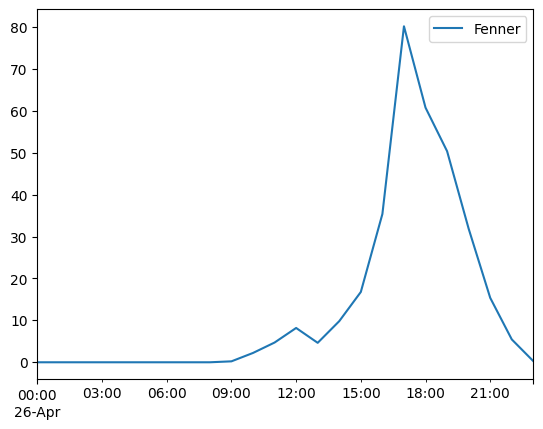

In [17]:
solar[solar.index.date==datetime.date(2000,4,26)].plot()

To access files stored in your Google Drive, you can mount your Drive to the Colab environment. This will allow your Python code to interact with files as if they were on a local file system.

<Axes: >

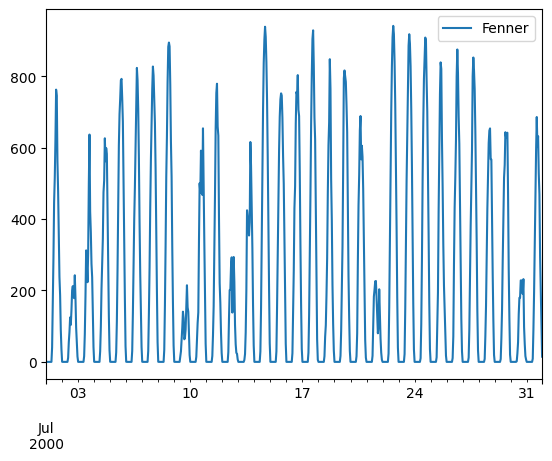

In [ ]:
ghi[(ghi.index.year==2000)&(ghi.index.month==7)].plot()

Once mounted, you can reference your files using paths like `/content/drive/My Drive/path/to/your/file.csv`.

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:975: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


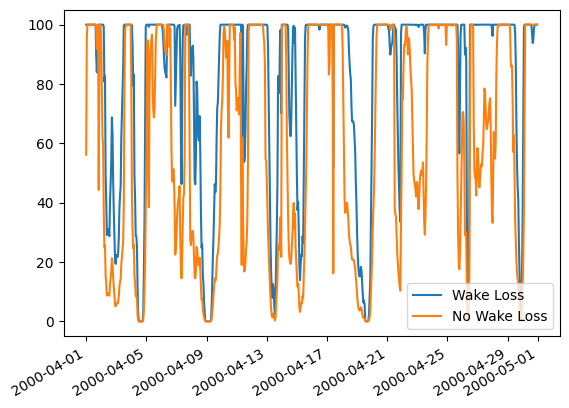

In [ ]:
ax = plt.subplot()
ax.plot(windNoWake[(wind.index.year==2000)&(wind.index.month==4)])
wind[(wind.index.year==2000)&(wind.index.month==4)].plot(ax=ax)
plt.legend(['Wake Loss','No Wake Loss'])
plt.show()

<Axes: >

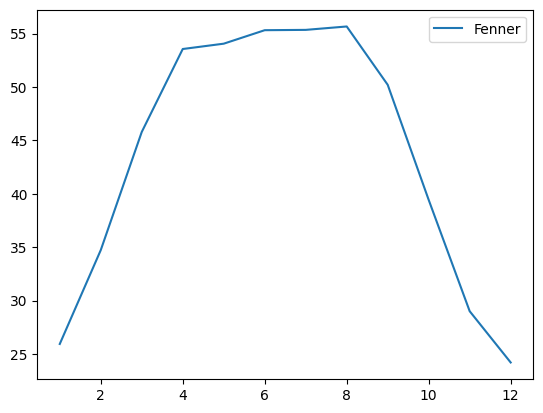

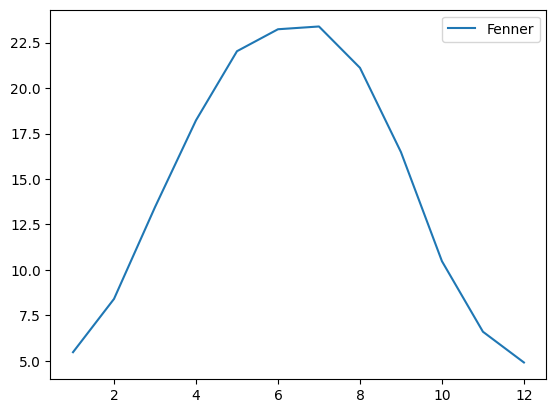

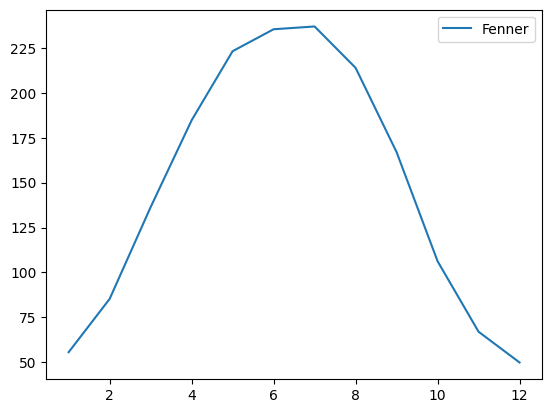

In [ ]:
solar.groupby(solar.index.month).mean().plot()
solar_firstsolar.groupby(solar_firstsolar.index.month).mean().plot()
ghi.groupby(ghi.index.month).mean().plot()


<Axes: >

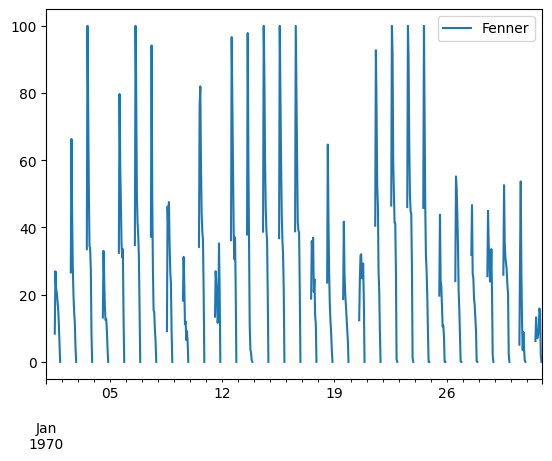

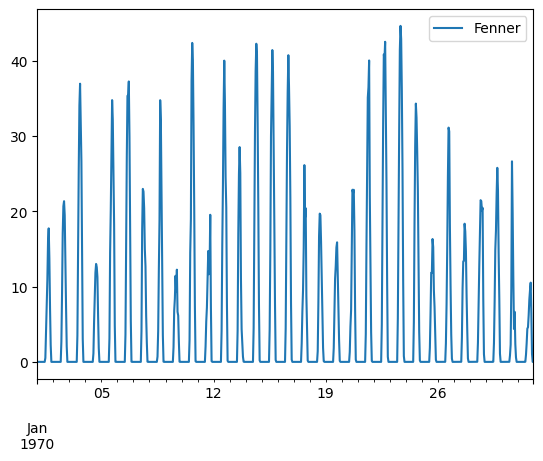

In [ ]:
solar[(solar.index.year==1970)&(solar.index.month==1)].plot()
solar_firstsolar[(solar_firstsolar.index.year==1970)&(solar_firstsolar.index.month==1)].plot()


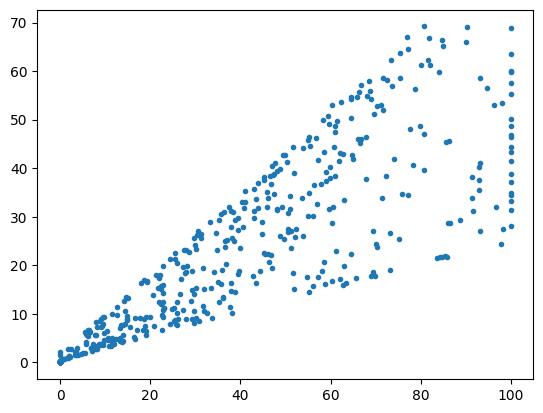

In [ ]:
plt.plot(solar.iloc[1000:2000],solar_firstsolar.iloc[1000:2000],'.')